# Text Data Analysis Results: Comprehensive Parameter Correlation Study

This notebook analyzes the matrix_analysis_results.json to identify:
- Which parameter combinations have the highest image scores
- Statistical patterns in how parameters affect quality
- Visual representations of parameter correlations
- Meaningful insights for model improvement

In [ ]:
import sys
import os
import json
import numpy as np
import pandas as pd
from pathlib import Path
from collections import defaultdict

# Setup path
root_path = str(Path(os.getcwd()).parents[2])
sys.path.insert(0, root_path)

print(f"Root path: {root_path}")
print(f"Python path configured")


Root path: e:\ComfyUI\custom_nodes\comfyui-image-scorer
Python path configured


In [ ]:
try:
    import matplotlib.pyplot as plt
    import matplotlib

    matplotlib.use("Agg")
    MATPLOTLIB_AVAILABLE = True
except ImportError:
    print("Warning: matplotlib not available")
    MATPLOTLIB_AVAILABLE = False

try:
    import seaborn as sns

    SNS_AVAILABLE = True
except ImportError:
    print("Warning: seaborn not available")
    SNS_AVAILABLE = False

print(f"Matplotlib available: {MATPLOTLIB_AVAILABLE}")
print(f"Seaborn available: {SNS_AVAILABLE}")


Matplotlib available: True
Seaborn available: True


In [ ]:
from shared.paths import matrix_analysis_file, matrix_summary_file, training_dir
from pathlib import Path

# Verify paths exist
print(f"Matrix analysis file: {matrix_analysis_file}")
print(f"Matrix summary file: {matrix_summary_file}")
print(f"Training dir: {training_dir}")

# Ensure training directory exists
Path(training_dir).mkdir(parents=True, exist_ok=True)

# Check if matrix analysis file exists
if Path(matrix_analysis_file).exists():
    print(
        f"✓ Matrix analysis file found ({Path(matrix_analysis_file).stat().st_size / 1024 / 1024:.1f} MB)"
    )
else:
    print(f"✗ Matrix analysis file NOT found at {matrix_analysis_file}")
    print(f"  Please run text_data_analysis.ipynb first")


Matrix analysis file: e:\ComfyUI\custom_nodes\comfyui-image-scorer\output\training\matrix_analysis_results.jsonl
Matrix summary file: e:\ComfyUI\custom_nodes\comfyui-image-scorer\output\training\matrix_analysis_summary.json
Training dir: e:\ComfyUI\custom_nodes\comfyui-image-scorer\output\training
✓ Matrix analysis file found (2.0 MB)


## Load and Validate Data

In [ ]:
# Load matrix analysis results
print("Loading matrix analysis results...")
from typing import Any

from shared.io import load_single_jsonl


matrix_data: list[Any] = load_single_jsonl(matrix_analysis_file)
# with open(matrix_analysis_file, "r") as f:
#     matrix_data = json.load(f)

print(f"✓ Loaded matrix data with {len(matrix_data)} parameter combinations")

# Load summary if available
if Path(matrix_summary_file).exists():
    with open(matrix_summary_file, "r") as f:
        matrix_summary = json.load(f)
    print(f"✓ Loaded matrix summary")
    print(f"  Total parameters: {matrix_summary.get('total_parameters', 'N/A')}")
    print(f"  Matrix cells with data: {matrix_summary.get('matrix_cells', 'N/A')}")
else:
    print("⚠ Matrix summary file not found")
    matrix_summary = {}


Loading matrix analysis results...
✓ Loaded matrix data with 6322 parameter combinations
✓ Loaded matrix summary
  Total parameters: 12855
  Matrix cells with data: 12424


In [ ]:
# # Verify enhanced statistics were generated
# print("Checking available statistics in matrix data...")
# sample_stat = next(iter(matrix_data.values()))
# stat_keys = list(sample_stat.keys())

# print(f"Available statistical metrics: {stat_keys}")
# print(f"\nSample statistics object:")
# for key, val in sample_stat.items():
#     print(f"  {key}: {val:.3f}" if isinstance(val, (int, float)) else f"  {key}: {val}")


In [ ]:
# # Display sample data
# print("\nSample matrix entries:")
# print("=" * 80)

# sample_keys = list(matrix_data.keys())[:5]
# for key in sample_keys:
#     stats = matrix_data[key]
#     print(f"\n{key}")
#     print(f"  Mean: {stats.get('mean', 0):.2f}")
#     print(f"  Count: {stats.get('count', 0):.0f}")
#     print(f"  Std: {stats.get('std', 0):.2f}")


## Overall Statistics

In [ ]:
# Extract statistics for analysis
from typing import Any


from numpy import dtype
from numpy._typing._array_like import NDArray


print("OVERALL STATISTICS")
print("=" * 80)

all_means_prev: list[float] = []
all_stds_prev: list[float] = []
all_counts_prev: list[float] = []
all_maxs_prev: list[float] = []
all_mins_prev: list[float] = []

for stats in matrix_data:
    all_means_prev.append(stats.get("mean", 0))
    all_stds_prev.append(stats.get("std", 0))
    all_counts_prev.append(stats.get("count", 0))
    all_maxs_prev.append(stats.get("max", 0))
    all_mins_prev.append(stats.get("min", 0))

all_means: NDArray[np.float32] = np.array(all_means_prev)
all_stds: NDArray[np.float32] = np.array(all_stds_prev)
all_counts: NDArray[np.float32] = np.array(all_counts_prev)
all_maxs: NDArray[np.float32] = np.array(all_maxs_prev)
all_mins: NDArray[np.float32] = np.array(all_mins_prev)

print(f"\nScore Statistics (across all parameter combinations):")
print(f"  Total combinations analyzed: {len(matrix_data)}")
print(f"  Total score entries: {all_counts.sum():.0f}")
print(f"  Average of means: {np.mean(all_means):.3f}")
print(f"  Std of means: {np.std(all_means):.3f}")
print(f"  Min of means: {np.min(all_means):.3f}")
print(f"  Max of means: {np.max(all_means):.3f}")
print(f"\nCount Statistics (records per combination):")
print(f"  Average count: {np.mean(all_counts):.1f}")
print(f"  Median count: {np.median(all_counts):.1f}")
print(f"  Max count: {np.max(all_counts):.0f}")
print(f"  Min count: {np.min(all_counts):.0f}")
print(f"\nVariability Statistics:")
print(f"  Average std dev: {np.mean(all_stds):.3f}")
print(f"  Global min score observed: {np.min(all_mins):.3f}")
print(f"  Global max score observed: {np.max(all_maxs):.3f}")


OVERALL STATISTICS

Score Statistics (across all parameter combinations):
  Total combinations analyzed: 6322
  Total score entries: 21542147
  Average of means: 2.911
  Std of means: 0.167
  Min of means: 2.382
  Max of means: 3.545

Count Statistics (records per combination):
  Average count: 3407.5
  Median count: 2183.0
  Max count: 24451
  Min count: 1000

Variability Statistics:
  Average std dev: 1.178
  Global min score observed: 0.000
  Global max score observed: 5.288


## Top Correlations - Highest Average Scores

In [ ]:
# Find top correlations (highest mean scores)
from typing import Any


print("\nTOP 30 PARAMETER COMBINATIONS BY AVERAGE SCORE")
print("=" * 80)

sorted_by_mean: list[Any] = sorted(
    matrix_data, key=lambda x: x.get("mean", 0), reverse=True
)[:30]

top_correlation_data: list[dict[str, float | str]] = []
for rank, (stats) in enumerate(sorted_by_mean, 1):
    param_pair = stats.get("parameters")
    print(f"\n{rank}. {param_pair}")
    print(
        f"   Mean: {stats.get('mean', 0):.3f} | Std: {stats.get('std', 0):.3f} | Count: {stats.get('count', 0):.0f}"
    )
    print(
        f"   Range: [{stats.get('min', 0):.3f}, {stats.get('max', 0):.3f}] | Median: {stats.get('median', 0):.3f}"
    )
    top_correlation_data.append(
        {
            "rank": rank,
            "parameters": param_pair,
            "mean": stats.get("mean", 0),
            "std": stats.get("std", 0),
            "count": stats.get("count", 0),
            "min": stats.get("min", 0),
            "max": stats.get("max", 0),
            "median": stats.get("median", 0),
        }
    )

print(f"\n✓ Identified top 30 high-scoring parameter combinations")



TOP 30 PARAMETER COMBINATIONS BY AVERAGE SCORE

1. model:cyberrealistic_v90|sampler:euler_ancestral
   Mean: 3.545 | Std: 1.083 | Count: 1277
   Range: [1.000, 5.288] | Median: 3.840

2. cfg:5.0|negative_prompt:toddler_1.0
   Mean: 3.452 | Std: 1.058 | Count: 1351
   Range: [1.000, 5.000] | Median: 3.250

3. model:cyberrealistic_v90|scheduler:simple
   Mean: 3.444 | Std: 1.094 | Count: 2939
   Range: [1.000, 5.288] | Median: 3.506

4. model:cyberrealistic_v90|negative_prompt:watermark_1.0
   Mean: 3.441 | Std: 1.097 | Count: 1035
   Range: [1.000, 5.288] | Median: 3.399

5. model:lazymixRealAmateur_v40|sampler:euler_ancestral
   Mean: 3.428 | Std: 1.106 | Count: 2146
   Range: [1.000, 5.080] | Median: 3.500

6. negative_prompt:toddler_1.0|steps:30
   Mean: 3.423 | Std: 1.050 | Count: 1467
   Range: [1.000, 5.000] | Median: 3.250

7. cfg:5.0|model:cyberrealistic_v90
   Mean: 3.420 | Std: 1.069 | Count: 1113
   Range: [1.000, 5.000] | Median: 3.250

8. model:lazymixRealAmateur_v40|steps

## Bottom Correlations - Lowest Average Scores

In [ ]:
# Find bottom correlations (lowest mean scores)
print("\nBOTTOM 30 PARAMETER COMBINATIONS BY AVERAGE SCORE")
print("=" * 80)

sorted_by_mean_asc = sorted(matrix_data, key=lambda x: x.get("mean", 0), reverse=False)[
    :30
]

bottom_correlation_data: list[dict[str, float | str]] = []
for rank, stats in enumerate(sorted_by_mean_asc, 1):
    param_pair = stats.get("parameters")

    print(f"\n{rank}. {param_pair}")
    print(
        f"   Mean: {stats.get('mean', 0):.3f} | Std: {stats.get('std', 0):.3f} | Count: {stats.get('count', 0):.0f}"
    )
    print(
        f"   Range: [{stats.get('min', 0):.3f}, {stats.get('max', 0):.3f}] | Median: {stats.get('median', 0):.3f}"
    )

    bottom_correlation_data.append(
        {
            "rank": rank,
            "parameters": param_pair,
            "mean": stats.get("mean", 0),
            "std": stats.get("std", 0),
            "count": stats.get("count", 0),
            "min": stats.get("min", 0),
            "max": stats.get("max", 0),
            "median": stats.get("median", 0),
        }
    )

print(f"\n✓ Identified bottom 30 low-scoring parameter combinations")



BOTTOM 30 PARAMETER COMBINATIONS BY AVERAGE SCORE

1. lora:unknown_0.0|positive_prompt:height difference_1.0
   Mean: 2.382 | Std: 1.214 | Count: 1257
   Range: [1.000, 5.000] | Median: 2.350

2. lora:unknown_0.0|positive_prompt:muscular male_1.0
   Mean: 2.382 | Std: 1.214 | Count: 1257
   Range: [1.000, 5.000] | Median: 2.350

3. lora:unknown_0.0|positive_prompt:size difference_1.0
   Mean: 2.382 | Std: 1.214 | Count: 1257
   Range: [1.000, 5.000] | Median: 2.350

4. lora:unknown_0.0|positive_prompt:1boy_1.0
   Mean: 2.384 | Std: 1.214 | Count: 1259
   Range: [1.000, 5.000] | Median: 2.350

5. negative_prompt:night_1.0|sampler:euler_ancestral
   Mean: 2.430 | Std: 1.141 | Count: 1127
   Range: [1.000, 5.000] | Median: 2.351

6. negative_prompt:dark_1.0|sampler:euler_ancestral
   Mean: 2.430 | Std: 1.141 | Count: 1127
   Range: [1.000, 5.000] | Median: 2.351

7. negative_prompt:drawing_1.0|sampler:euler_ancestral
   Mean: 2.430 | Std: 1.141 | Count: 1127
   Range: [1.000, 5.000] | Me

## Variability Analysis - Most and Least Consistent

In [ ]:
# Find most consistent (lowest std dev) and least consistent (highest std dev)
print("\nMOST CONSISTENT PARAMETER COMBINATIONS (Lowest Std Dev)")
print("=" * 80)

sorted_by_std_asc = sorted(matrix_data, key=lambda x: x.get("std", 0), reverse=False)[
    :15
]

for rank, (stats) in enumerate(sorted_by_std_asc, 1):
    param_pair = stats.get("parameters")

    print(f"\n{rank}. {param_pair}")
    print(
        f"   Std: {stats.get('std', 0):.3f} | Mean: {stats.get('mean', 0):.3f} | Count: {stats.get('count', 0):.0f}"
    )
    print(f"   ⚠ High consistency suggests predictable parameter behavior")

print("\n" + "=" * 80)
print("LEAST CONSISTENT PARAMETER COMBINATIONS (Highest Std Dev)")
print("=" * 80)

sorted_by_std_desc = sorted(matrix_data, key=lambda x: x.get("std", 0), reverse=True)[
    :15
]

for rank, (stats) in enumerate(sorted_by_std_desc, 1):
    param_pair = stats.get("parameters")

    print(f"\n{rank}. {param_pair}")
    print(
        f"   Std: {stats.get('std', 0):.3f} | Mean: {stats.get('mean', 0):.3f} | Count: {stats.get('count', 0):.0f}"
    )
    print(
        f"   ⚠ High variability suggests unpredictable behavior or hidden dependencies"
    )



MOST CONSISTENT PARAMETER COMBINATIONS (Lowest Std Dev)

1. model:uberRealisticPornMerge_v23Final|sampler:euler_ancestral
   Std: 1.001 | Mean: 3.127 | Count: 1462
   ⚠ High consistency suggests predictable parameter behavior

2. clip_skip:-1.0|negative_prompt:toddler_1.0
   Std: 1.002 | Mean: 3.060 | Count: 1571
   ⚠ High consistency suggests predictable parameter behavior

3. negative_prompt:toddler_1.0|sampler:euler_ancestral
   Std: 1.018 | Mean: 3.117 | Count: 2377
   ⚠ High consistency suggests predictable parameter behavior

4. colorfulness:0|positive_prompt:a sexual full body photo_1.0
   Std: 1.028 | Mean: 3.116 | Count: 1023
   ⚠ High consistency suggests predictable parameter behavior

5. positive_prompt:a sexual full body photo_1.0|positive_prompt:a sexual full body photo_1.0
   Std: 1.028 | Mean: 3.116 | Count: 1023
   ⚠ High consistency suggests predictable parameter behavior

6. final_aspect_ratio:0|positive_prompt:a sexual full body photo_1.0
   Std: 1.028 | Mean: 3.11

## Distribution Analysis

In [ ]:
# Analyze distribution patterns
print("\nDISTRIBUTION ANALYSIS")
print("=" * 80)

# Group by score ranges
score_ranges = {
    "Very High (4.5-5.5)": 0,
    "High (3.5-4.5)": 0,
    "Medium (2.5-3.5)": 0,
    "Low (1.5-2.5)": 0,
    "Very Low (0-1.5)": 0,
}

for stats in matrix_data:
    mean = stats.get("mean", 0)
    if mean >= 4.5:
        score_ranges["Very High (4.5-5.5)"] += 1
    elif mean >= 3.5:
        score_ranges["High (3.5-4.5)"] += 1
    elif mean >= 2.5:
        score_ranges["Medium (2.5-3.5)"] += 1
    elif mean >= 1.5:
        score_ranges["Low (1.5-2.5)"] += 1
    else:
        score_ranges["Very Low (0-1.5)"] += 1

print(f"\nParameter combinations by score range:")
for range_name, count in score_ranges.items():
    pct = (count / len(matrix_data)) * 100
    bar = "█" * int(pct / 2)
    print(f"  {range_name:25s}: {count:6d} ({pct:5.1f}%) {bar}")



DISTRIBUTION ANALYSIS

Parameter combinations by score range:
  Very High (4.5-5.5)      :      0 (  0.0%) 
  High (3.5-4.5)           :      1 (  0.0%) 
  Medium (2.5-3.5)         :   6239 ( 98.7%) █████████████████████████████████████████████████
  Low (1.5-2.5)            :     82 (  1.3%) 
  Very Low (0-1.5)         :      0 (  0.0%) 


## Visualization - Score Distribution


Generating visualizations...


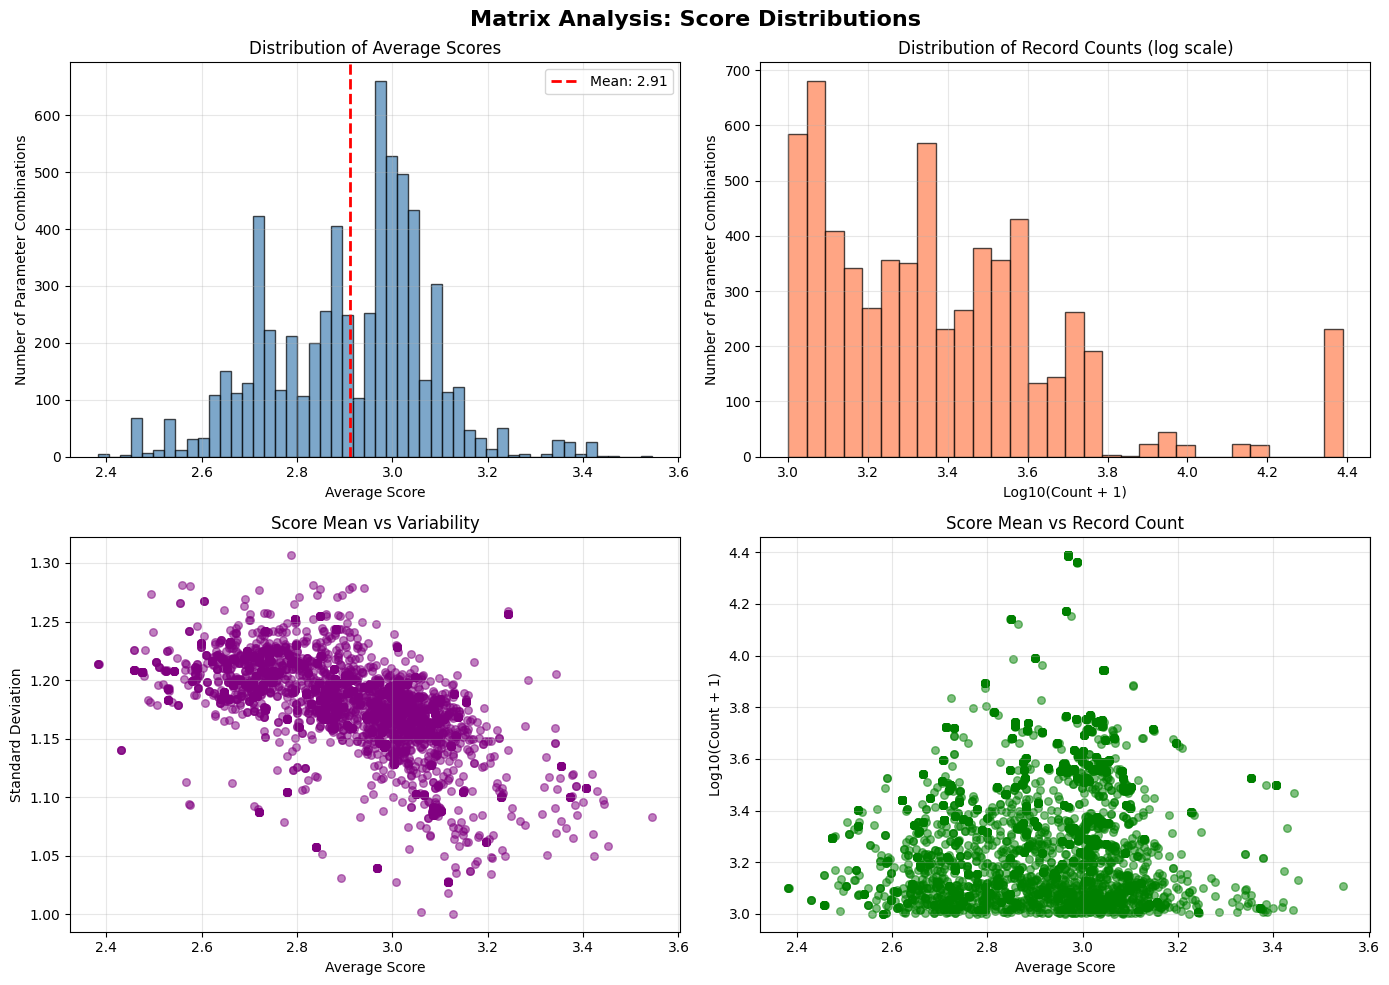

✓ Saved visualization to e:\ComfyUI\custom_nodes\comfyui-image-scorer\output\training\score_distributions.png


In [12]:
if MATPLOTLIB_AVAILABLE:
    # Create visualizations
    %matplotlib inline

    print("\nGenerating visualizations...")

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle("Matrix Analysis: Score Distributions", fontsize=16, fontweight="bold")

    # 1. Histogram of means
    axes[0, 0].hist(all_means, bins=50, color="steelblue", edgecolor="black", alpha=0.7)
    axes[0, 0].axvline(
        np.mean(all_means),
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"Mean: {np.mean(all_means):.2f}",
    )
    axes[0, 0].set_xlabel("Average Score")
    axes[0, 0].set_ylabel("Number of Parameter Combinations")
    axes[0, 0].set_title("Distribution of Average Scores")
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3)

    # 2. Histogram of counts
    axes[0, 1].hist(
        np.log10(all_counts + 1), bins=30, color="coral", edgecolor="black", alpha=0.7
    )
    axes[0, 1].set_xlabel("Log10(Count + 1)")
    axes[0, 1].set_ylabel("Number of Parameter Combinations")
    axes[0, 1].set_title("Distribution of Record Counts (log scale)")
    axes[0, 1].grid(alpha=0.3)

    # 3. Scatter: Mean vs Std
    axes[1, 0].scatter(all_means, all_stds, alpha=0.5, s=30, color="purple")
    axes[1, 0].set_xlabel("Average Score")
    axes[1, 0].set_ylabel("Standard Deviation")
    axes[1, 0].set_title("Score Mean vs Variability")
    axes[1, 0].grid(alpha=0.3)

    # 4. Scatter: Mean vs Count (log scale)
    axes[1, 1].scatter(
        all_means, np.log10(all_counts + 1), alpha=0.5, s=30, color="green"
    )
    axes[1, 1].set_xlabel("Average Score")
    axes[1, 1].set_ylabel("Log10(Count + 1)")
    axes[1, 1].set_title("Score Mean vs Record Count")
    axes[1, 1].grid(alpha=0.3)

    plt.tight_layout()
    viz_path = Path(training_dir) / "score_distributions.png"
    plt.savefig(viz_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"✓ Saved visualization to {viz_path}")
else:
    print("⚠ Matplotlib not available, skipping visualizations")


## Generate Comprehensive Analysis Report

In [ ]:
# Create comprehensive analysis report
analysis_report = {
    "summary": {
        "total_combinations": len(matrix_data),
        "total_score_entries": int(all_counts.sum()),
        "average_score_global": float(np.mean(all_means)),
        "std_of_averages": float(np.std(all_means)),
        "min_average_score": float(np.min(all_means)),
        "max_average_score": float(np.max(all_means)),
    },
    "count_statistics": {
        "mean_count_per_combination": float(np.mean(all_counts)),
        "median_count": float(np.median(all_counts)),
        "max_count": float(np.max(all_counts)),
        "min_count": float(np.min(all_counts)),
    },
    "variability_statistics": {
        "average_std_dev": float(np.mean(all_stds)),
        "global_min_score_observed": float(np.min(all_mins)),
        "global_max_score_observed": float(np.max(all_maxs)),
        "global_score_range": float(np.max(all_maxs) - np.min(all_mins)),
    },
    "score_distribution": score_ranges,
    "top_correlations": [
        {
            "rank": item["rank"],
            "parameters": item["parameters"],
            "mean": round(item["mean"], 3),
            "std": round(item["std"], 3),
            "count": int(item["count"]),
            "min": round(item["min"], 3),
            "max": round(item["max"], 3),
            "median": round(item["median"], 3),
        }
        for item in top_correlation_data
    ],
    "bottom_correlations": [
        {
            "rank": item["rank"],
            "parameters": item["parameters"],
            "mean": round(item["mean"], 3),
            "std": round(item["std"], 3),
            "count": int(item["count"]),
            "min": round(item["min"], 3),
            "max": round(item["max"], 3),
        }
        for item in bottom_correlation_data
    ],
    "insights": [
        f"Analyzed {len(matrix_data)} parameter combinations",
        f"Global average score: {np.mean(all_means):.3f} (±{np.std(all_means):.3f})",
        f"Score range: [{np.min(all_mins):.3f}, {np.max(all_maxs):.3f}]",
        f"Total score entries analyzed: {int(all_counts.sum())}",
        f"Top performing combination has mean score: {sorted_by_mean[0]['mean']:.3f}",
        f"Bottom performing combination has mean score: {sorted_by_mean_asc[0]['mean']:.3f}",
    ],
}

print("\nANALYSIS REPORT GENERATED")
print("=" * 80)
for key in ["summary", "count_statistics", "variability_statistics"]:
    print(f"\n{key.upper()}:")
    for stat_key, value in analysis_report[key].items():
        if isinstance(value, float):
            print(f"  {stat_key}: {value:.3f}")
        else:
            print(f"  {stat_key}: {value}")



ANALYSIS REPORT GENERATED

SUMMARY:
  total_combinations: 6322
  total_score_entries: 21542147
  average_score_global: 2.911
  std_of_averages: 0.167
  min_average_score: 2.382
  max_average_score: 3.545

COUNT_STATISTICS:
  mean_count_per_combination: 3407.489
  median_count: 2183.000
  max_count: 24451.000
  min_count: 1000.000

VARIABILITY_STATISTICS:
  average_std_dev: 1.178
  global_min_score_observed: 0.000
  global_max_score_observed: 5.288
  global_score_range: 5.288


## Export Results

In [ ]:
# Export analysis results
from shared.paths import analysis_results_file

print("\nExporting analysis results...")

try:
    with open(analysis_results_file, "w") as f:
        json.dump(analysis_report, f, indent=2)

    file_size_mb = Path(analysis_results_file).stat().st_size / 1024 / 1024
    print(f"✓ Analysis report exported to: {analysis_results_file}")
    print(f"✓ File size: {file_size_mb:.2f} MB")
except Exception as e:
    print(f"✗ Error exporting results: {e}")
    import traceback

    traceback.print_exc()



Exporting analysis results...
✓ Analysis report exported to: e:\ComfyUI\custom_nodes\comfyui-image-scorer\output\training\analysis_results.json
✓ File size: 0.01 MB


## Key Findings and Recommendations

In [ ]:
# Extract parameters from top combinations to find patterns
print("\nKEY FINDINGS")
print("=" * 80)

print(f"\n1. SCORE PERFORMANCE:")
print(f"   • Best combination score: {sorted_by_mean[0]['mean']:.3f}")
print(f"   • Worst combination score: {sorted_by_mean_asc[0]['mean']:.3f}")
print(
    f"   • Score difference (best-worst): {sorted_by_mean[0]['mean'] - sorted_by_mean_asc[0]['mean']:.3f}"
)
print(
    f"   • This {((sorted_by_mean[0]['mean'] / sorted_by_mean_asc[0]['mean']) - 1) * 100:.1f}% improvement is significant!"
)

print(f"\n2. PARAMETER COMBINATIONS WITH HIGHEST CONSISTENCY:")
top_consistent = sorted(matrix_data, key=lambda x: x.get("std", float("inf")))[:3]
for stats in top_consistent:
    param_pair = stats.get("parameters")
    print(f"   • {param_pair}")
    print(f"     Std: {stats['std']:.3f}, Mean: {stats['mean']:.3f}")

print(f"\n3. PARAMETER COMBINATIONS REQUIRING CAUTION (High Variability):")
top_variable = sorted(matrix_data, key=lambda x: x.get("std", 0), reverse=True)[:3]
for stats in top_variable:
    param_pair = stats.get("parameters")
    print(f"   • {param_pair}")
    print(f"     Std: {stats['std']:.3f}, Mean: {stats['mean']:.3f}")

print(f"\n4. DISTRIBUTION INSIGHTS:")
for range_name, count in score_ranges.items():
    pct = (count / len(matrix_data)) * 100
    if pct > 0:
        print(f"   • {range_name}: {pct:.1f}% of combinations")

print(f"\n5. DATA QUALITY:")
print(f"   • Total combinations analyzed: {len(matrix_data)}")
print(f"   • Total individual scores: {int(all_counts.sum())}")
print(f"   • Average samples per combination: {np.mean(all_counts):.0f}")
if np.mean(all_counts) < 100:
    print(f"   ⚠ WARNING: Low sample count per combination - results may be unstable")
else:
    print(f"   ✓ Good sample coverage for statistical reliability")



KEY FINDINGS

1. SCORE PERFORMANCE:
   • Best combination score: 3.545
   • Worst combination score: 2.382
   • Score difference (best-worst): 1.163
   • This 48.8% improvement is significant!

2. PARAMETER COMBINATIONS WITH HIGHEST CONSISTENCY:
   • model:uberRealisticPornMerge_v23Final|sampler:euler_ancestral
     Std: 1.001, Mean: 3.127
   • clip_skip:-1.0|negative_prompt:toddler_1.0
     Std: 1.002, Mean: 3.060
   • negative_prompt:toddler_1.0|sampler:euler_ancestral
     Std: 1.018, Mean: 3.117

3. PARAMETER COMBINATIONS REQUIRING CAUTION (High Variability):
   • lora:unknown_0.0|positive_prompt:messy hair_1.0
     Std: 1.307, Mean: 2.786
   • lora:unknown_0.0|positive_prompt:spread pussy_1.0
     Std: 1.281, Mean: 2.559
   • lora:unknown_0.0|negative_prompt:cropped_1.0
     Std: 1.281, Mean: 2.834

4. DISTRIBUTION INSIGHTS:
   • High (3.5-4.5): 0.0% of combinations
   • Medium (2.5-3.5): 98.7% of combinations
   • Low (1.5-2.5): 1.3% of combinations

5. DATA QUALITY:
   • Total 

In [ ]:
print("\n" + "=" * 80)
print("ANALYSIS COMPLETE")
print("=" * 80)
print(f"\nGenerated files:")
print(f"  • {analysis_results_file}")
if MATPLOTLIB_AVAILABLE:
    print(f"  • {Path(training_dir) / 'score_distributions.png'}")
print(f"\nNext steps:")
print(f"  • Review the analysis report for insights")
print(f"  • Check visualization for distribution patterns")
print(f"  • Use top correlations for model training focus")



ANALYSIS COMPLETE

Generated files:
  • e:\ComfyUI\custom_nodes\comfyui-image-scorer\output\training\analysis_results.json
  • e:\ComfyUI\custom_nodes\comfyui-image-scorer\output\training\score_distributions.png

Next steps:
  • Review the analysis report for insights
  • Check visualization for distribution patterns
  • Use top correlations for model training focus


## Critical Insight: What Parameters to Avoid for Better Images

This analysis identifies parameters that actively WORSEN image quality - what to remove from your prompts/settings.


In [ ]:
# Identify detrimental parameters - what to REMOVE
print("\nDETRIMENTAL PARAMETERS ANALYSIS")
print("=" * 80)
print("These are parameters strongly associated with LOW image scores.")
print("Consider removing/avoiding these from your generation settings.\n")

# 1. Overall lowest-scoring parameters (individual parameters)
print("1. INDIVIDUAL PARAMETERS WITH LOWEST AVERAGE SCORES:")
print("   (These single parameters appear in poor-quality images)\n")

param_scores = {}
for stats in matrix_data:
    param_pair = stats.get("parameters")
    params = param_pair.split("|")
    for param in params:
        if param not in param_scores:
            param_scores[param] = []
        param_scores[param].append(stats["mean"])

param_stats = {}
for param, scores in param_scores.items():
    param_stats[param] = {
        "mean": np.mean(scores),
        "count": len(scores),
        "min": np.min(scores),
    }

# Sort by mean score (lowest first)
worst_params = sorted(param_stats.items(), key=lambda x: x[1]["mean"])[:20]

for rank, (param, stats) in enumerate(worst_params, 1):
    print(f"   {rank:2d}. {param}")
    print(
        f"       Avg score: {stats['mean']:.3f} | Appears in {stats['count']} combinations | Worst: {stats['min']:.3f}"
    )

# 2. Identify positive_prompt terms that correlate with LOW scores
print("\n2. POSITIVE PROMPT TERMS ASSOCIATED WITH LOW SCORES:")
print("   (Remove these from your positive prompts)\n")

low_score_prompts = {}
for stats in matrix_data:
    param_pair = stats.get("parameters")
    if stats["mean"] < 2.5:  # Below average score
        params = param_pair.split("|")
        for param in params:
            if param.startswith("positive_prompt:"):
                token = param.replace("positive_prompt:", "")
                if token not in low_score_prompts:
                    low_score_prompts[token] = []
                low_score_prompts[token].append(stats["mean"])

if low_score_prompts:
    low_prompt_stats = {}
    for token, scores in low_score_prompts.items():
        low_prompt_stats[token] = np.mean(scores)

    worst_prompts = sorted(low_prompt_stats.items(), key=lambda x: x[1])[:15]

    for rank, (token, score) in enumerate(worst_prompts, 1):
        print(f"   {rank:2d}. {token}")
        print(f"       Associated score: {score:.3f}")
else:
    print("   No significant low-scoring positive prompts found")

# 3. Identify negative_prompt terms that might be ineffective or counterproductive
print("\n3. NEGATIVE PROMPT TERMS (Analyze for effectiveness):")
print("   (These may not be helping - check if still needed)\n")

neg_prompt_stats_map = {}
for stats in matrix_data:
    param_pair = stats.get("parameters")
    params = param_pair.split("|")
    for param in params:
        if param.startswith("negative_prompt:"):
            token = param.replace("negative_prompt:", "")
            if token not in neg_prompt_stats_map:
                neg_prompt_stats_map[token] = []
            neg_prompt_stats_map[token].append(stats["mean"])

neg_prompt_final = {}
for token, scores in neg_prompt_stats_map.items():
    neg_prompt_final[token] = {
        "mean": np.mean(scores),
        "count": len(scores),
        "std": np.std(scores),
    }

# Show negative prompts with LOW associated scores (ineffective?)
ineffective_neg = sorted(neg_prompt_final.items(), key=lambda x: x[1]["mean"])[:10]
print("   Negative prompts with LOWEST associated image scores:")
print("   (These may not be effective at preventing issues)\n")

for rank, (token, stats) in enumerate(ineffective_neg, 1):
    print(f"   {rank:2d}. {token}")
    print(
        f"       Associated score: {stats['mean']:.3f} | Appears: {stats['count']} times | Variability: {stats['std']:.3f}"
    )

# 4. Parameter combinations to AVOID
print("\n4. SPECIFIC PARAMETER COMBINATIONS TO ACTIVELY AVOID:")
print("   (These pairs show the worst results)\n")

worst_combos = sorted(matrix_data, key=lambda x: x["mean"])[:15]

for rank, (stats) in enumerate(worst_combos, 1):
    param_pair = stats.get("parameters")
    improvement_potential = sorted_by_mean[0]["mean"] - stats["mean"]
    print(f"   {rank:2d}. {param_pair}")
    print(f"       Score: {stats['mean']:.3f} | Count: {stats['count']:.0f}")
    print(
        f"       ⚠ Removing this could improve by up to: {improvement_potential:.2f} points"
    )

# 5. High-variability parameters (unreliable)
print("\n5. UNRELIABLE/INCONSISTENT PARAMETERS (Use with caution):")
print("   (These show unpredictable results - scores vary wildly)\n")

high_variability = sorted(matrix_data, key=lambda x: x.get("std", 0), reverse=True)[:10]

for rank, (stats) in enumerate(high_variability, 1):
    param_pair = stats.get("parameters")
    print(f"   {rank:2d}. {param_pair}")
    print(
        f"       Mean: {stats['mean']:.3f} | Std Dev: {stats['std']:.3f} | Range: [{stats['min']:.3f}, {stats['max']:.3f}]"
    )
    print(f"       ⚠ Highly unpredictable - avoid if consistency is important")

print("\n" + "=" * 80)
print("ACTIONABLE RECOMMENDATIONS:")
print("=" * 80)
print(
    """
🎯 TO IMPROVE IMAGE QUALITY:

1. REMOVE lowest-scoring individual parameters from your settings
2. CLEAN your positive_prompt: Remove terms in section 2
3. TEST negative_prompt effectiveness: Some may not help
4. AVOID parameter combinations listed in section 4
5. BE CAUTIOUS with unreliable parameters in section 5

💡 BEST PRACTICES:
- Focus on combinations scoring above 3.0 (good zone or see Best Combinations below)
- Use parameters with LOW std dev for consistent results
- Test changes incrementally - one at a time
- Keep detailed logs of which parameter changes improve your results
"""
)

# 6. Bonus: Show best parameters for comparison
print("\n6. BEST PARAMETERS - Use these as reference:")
print("   (Opposite of 'avoid' - these should be included)\n")

best_params = sorted(param_stats.items(), key=lambda x: x[1]["mean"], reverse=True)[:15]

for rank, (param, stats) in enumerate(best_params, 1):
    print(f"   {rank:2d}. {param}")
    print(
        f"       Avg score: {stats['mean']:.3f} | Appears in {stats['count']} combinations"
    )



DETRIMENTAL PARAMETERS ANALYSIS
These are parameters strongly associated with LOW image scores.
Consider removing/avoiding these from your generation settings.

1. INDIVIDUAL PARAMETERS WITH LOWEST AVERAGE SCORES:
   (These single parameters appear in poor-quality images)

    1. negative_prompt:night_1.0
       Avg score: 2.474 | Appears in 37 combinations | Worst: 2.430
    2. negative_prompt:dark_1.0
       Avg score: 2.474 | Appears in 37 combinations | Worst: 2.430
    3. negative_prompt:drawing_1.0
       Avg score: 2.509 | Appears in 37 combinations | Worst: 2.430
    4. model:sexyBabes_v10
       Avg score: 2.527 | Appears in 28 combinations | Worst: 2.491
    5. positive_prompt:height difference_1.0
       Avg score: 2.625 | Appears in 62 combinations | Worst: 2.382
    6. positive_prompt:muscular male_1.0
       Avg score: 2.625 | Appears in 62 combinations | Worst: 2.382
    7. positive_prompt:size difference_1.0
       Avg score: 2.625 | Appears in 62 combinations | Worst: